In [90]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_10_11.csv to online_retail_10_11 (1).csv


In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [92]:
df = pd.read_csv("online_retail_10_11.csv")

In [93]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [94]:
df.shape

(541910, 8)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   UnitPrice    541910 non-null  float64
 6   CustomerID   406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [96]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [97]:
df = df.dropna(subset=['CustomerID'])
print(df.shape)

(406830, 8)


In [98]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(8905)

In [99]:
(df['Quantity'] < 0).sum()

np.int64(8905)

In [100]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [101]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [102]:
df.shape

(397885, 8)

In [103]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [104]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [105]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [106]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [107]:
customer_spending = df.groupby('CustomerID')['TotalAmount'].sum()

In [108]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

In [109]:
customer_quantity = df.groupby('CustomerID')['Quantity'].sum()

In [110]:
customer_products = df.groupby('CustomerID')['StockCode'].nunique()

In [111]:
customer_aov = customer_spending / customer_orders

In [112]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [113]:
customer_last_purchase = df.groupby('CustomerID')['InvoiceDate'].max()

In [114]:
reference_date = df['InvoiceDate'].max()

customer_recency = (reference_date - customer_last_purchase).dt.days

In [115]:
customer_data = pd.concat([
    customer_spending,
    customer_orders,
    customer_quantity,
    customer_products,
    customer_aov,
    customer_recency
], axis=1)

In [116]:
customer_data.head()

,TotalAmount,InvoiceNo,Quantity,StockCode,0,InvoiceDate
CustomerID,,,,,,
12346.0,77183.60,1,74215,1,77183.600000,325
12347.0,4310.00,7,2458,103,615.714286,1
12348.0,1797.24,4,2341,22,449.310000,74
12349.0,1757.55,1,631,73,1757.550000,18
12350.0,334.40,1,197,17,334.400000,309


In [117]:
customer_data.columns = [
    'TotalSpending',
    'NumberOfOrders',
    'TotalQuantity',
    'UniqueProducts',
    'AverageOrderValue',
    'Recency'
]

In [118]:
customer_data.head()

,TotalSpending,NumberOfOrders,TotalQuantity,UniqueProducts,AverageOrderValue,Recency
CustomerID,,,,,,
12346.0,77183.60,1,74215,1,77183.600000,325
12347.0,4310.00,7,2458,103,615.714286,1
12348.0,1797.24,4,2341,22,449.310000,74
12349.0,1757.55,1,631,73,1757.550000,18
12350.0,334.40,1,197,17,334.400000,309


In [119]:
customer_data.isnull().sum()

,0
TotalSpending,0
NumberOfOrders,0
TotalQuantity,0
UniqueProducts,0
AverageOrderValue,0
Recency,0


In [120]:
customer_data.describe()

,TotalSpending,NumberOfOrders,TotalQuantity,UniqueProducts,AverageOrderValue,Recency
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,2054.270609,4.272015,1191.289304,61.501153,419.167327,91.536422
std,8989.229895,7.697998,5046.081512,85.366768,1796.537828,100.014169
min,3.750000,1.000000,1.000000,1.000000,3.450000,0.000000
25%,307.415000,1.000000,160.000000,16.000000,178.625000,17.000000
50%,674.485000,2.000000,379.000000,35.000000,293.900000,50.000000
75%,1661.740000,5.000000,992.750000,77.000000,430.113750,141.000000
max,280206.020000,209.000000,196915.000000,1787.000000,84236.250000,373.000000


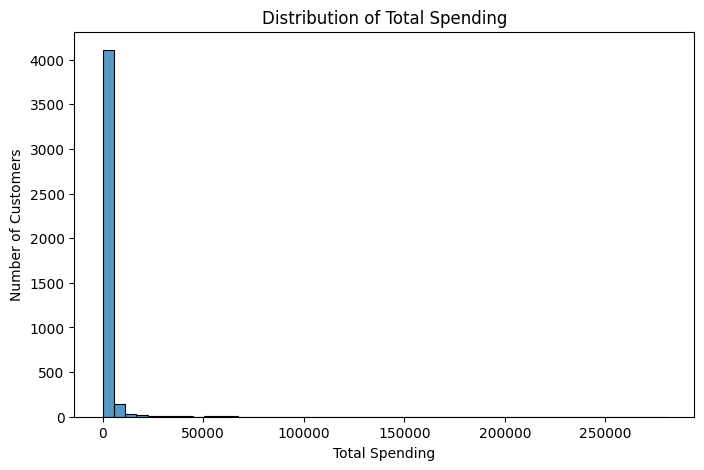

In [121]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_data['TotalSpending'], bins=50)

plt.title('Distribution of Total Spending')
plt.xlabel('Total Spending')
plt.ylabel('Number of Customers')

plt.show()

In [122]:
customer_features = customer_data.copy()

In [123]:
customer_features['TotalSpending'] = np.log1p(
    customer_features['TotalSpending']
)

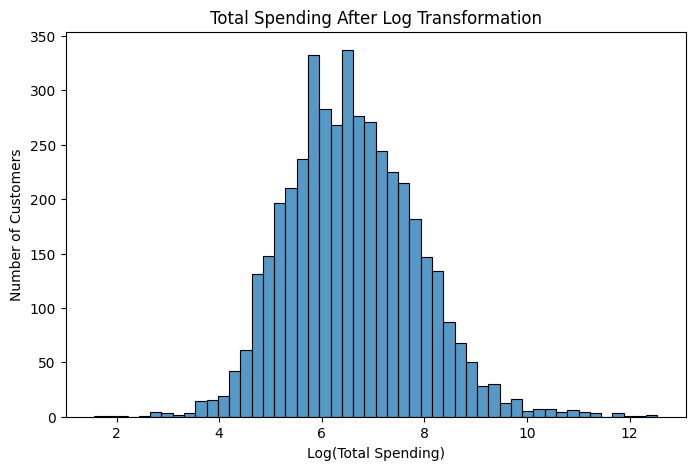

In [124]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_features['TotalSpending'], bins=50)

plt.title('Total Spending After Log Transformation')
plt.xlabel('Log(Total Spending)')
plt.ylabel('Number of Customers')

plt.show()

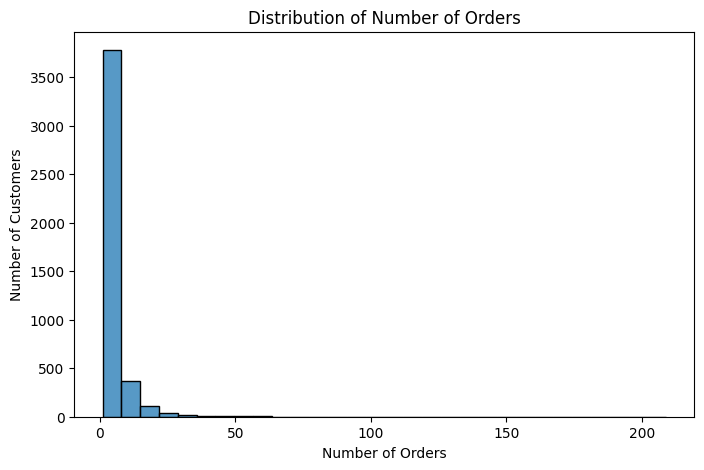

In [125]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_data['NumberOfOrders'], bins=30)

plt.title('Distribution of Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')

plt.show()

In [126]:
customer_features['NumberOfOrders'] = np.log1p(
    customer_features['NumberOfOrders']
)

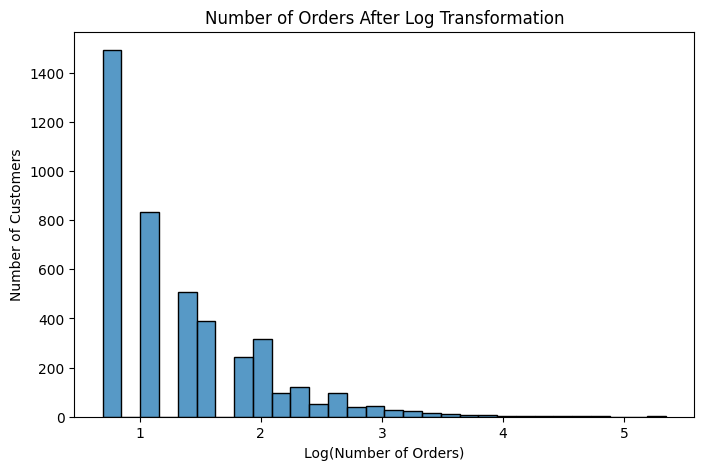

In [127]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_features['NumberOfOrders'], bins=30)

plt.title('Number of Orders After Log Transformation')
plt.xlabel('Log(Number of Orders)')
plt.ylabel('Number of Customers')

plt.show()

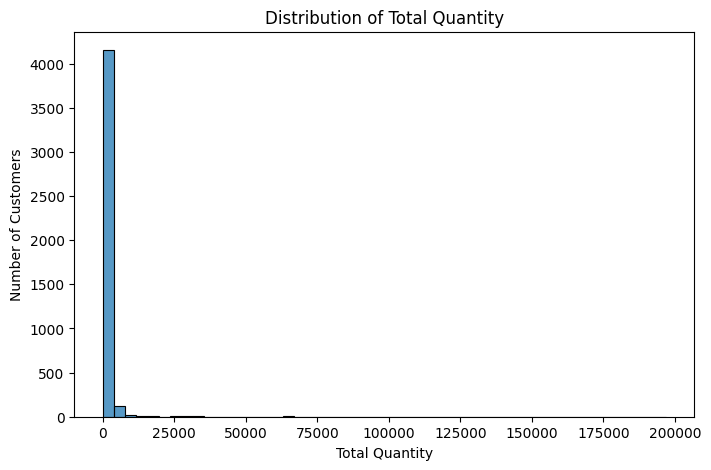

In [128]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_data['TotalQuantity'], bins=50)

plt.title('Distribution of Total Quantity')
plt.xlabel('Total Quantity')
plt.ylabel('Number of Customers')

plt.show()

In [129]:
customer_features['TotalQuantity'] = np.log1p(
    customer_features['TotalQuantity']
)

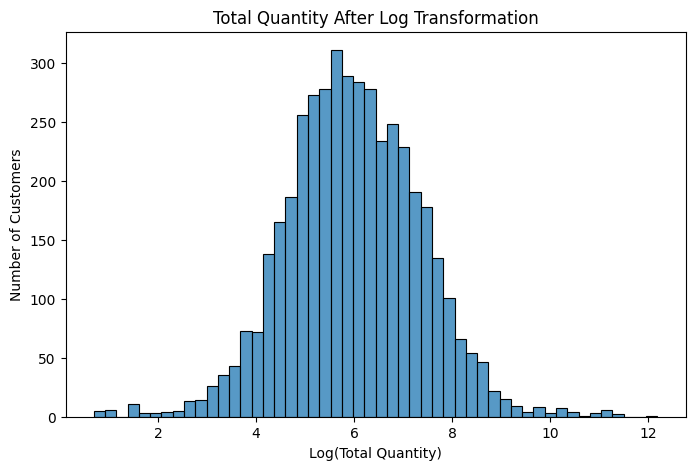

In [130]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_features['TotalQuantity'], bins=50)

plt.title('Total Quantity After Log Transformation')
plt.xlabel('Log(Total Quantity)')
plt.ylabel('Number of Customers')

plt.show()

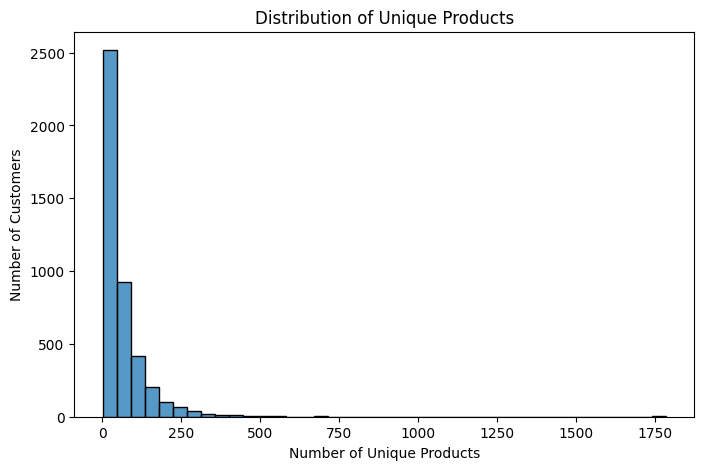

In [131]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_data['UniqueProducts'], bins=40)

plt.title('Distribution of Unique Products')
plt.xlabel('Number of Unique Products')
plt.ylabel('Number of Customers')

plt.show()

In [132]:
customer_features['UniqueProducts'] = np.log1p(
    customer_features['UniqueProducts']
)

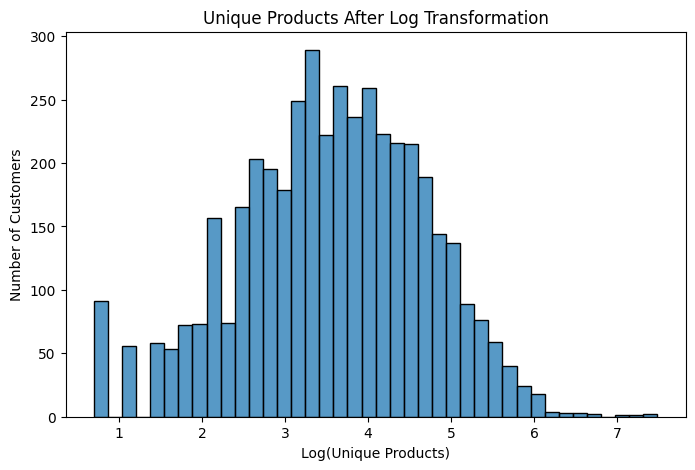

In [133]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_features['UniqueProducts'], bins=40)

plt.title('Unique Products After Log Transformation')
plt.xlabel('Log(Unique Products)')
plt.ylabel('Number of Customers')

plt.show()

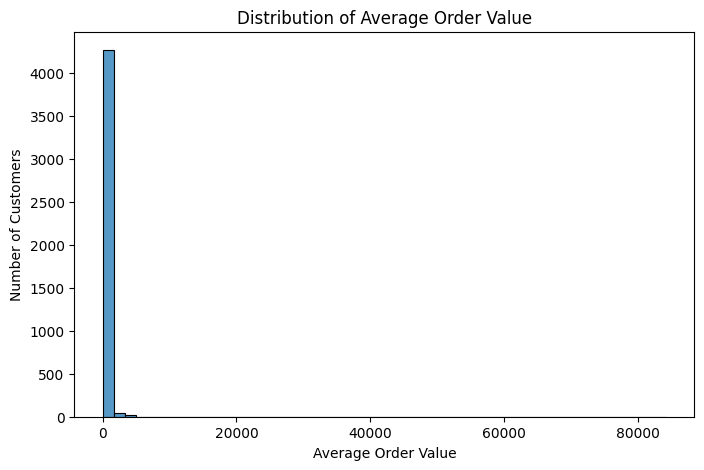

In [134]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_data['AverageOrderValue'], bins=50)

plt.title('Distribution of Average Order Value')
plt.xlabel('Average Order Value')
plt.ylabel('Number of Customers')

plt.show()

In [135]:
customer_features['AverageOrderValue'] = np.log1p(
    customer_features['AverageOrderValue']
)

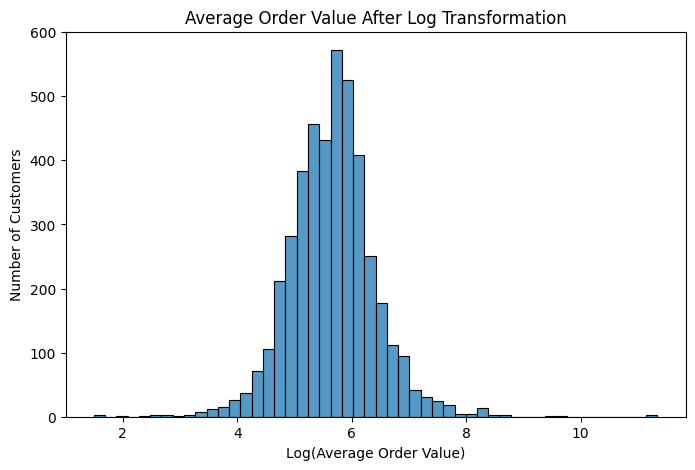

In [136]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_features['AverageOrderValue'], bins=50)

plt.title('Average Order Value After Log Transformation')
plt.xlabel('Log(Average Order Value)')
plt.ylabel('Number of Customers')

plt.show()

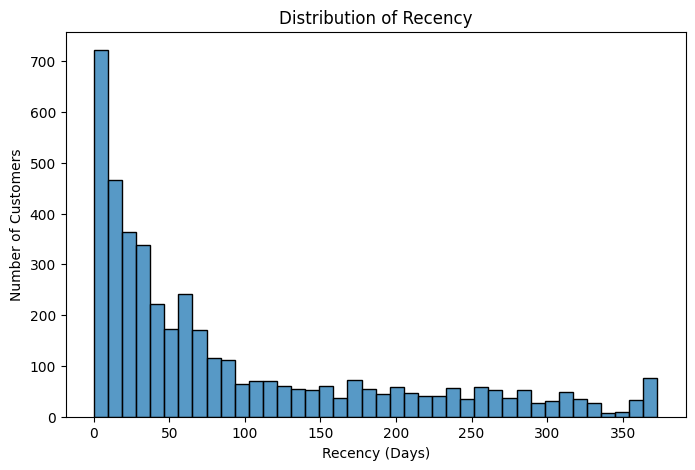

In [137]:
plt.figure(figsize=(8, 5))

sns.histplot(customer_data['Recency'], bins=40)

plt.title('Distribution of Recency')
plt.xlabel('Recency (Days)')
plt.ylabel('Number of Customers')

plt.show()

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(customer_features)

In [139]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

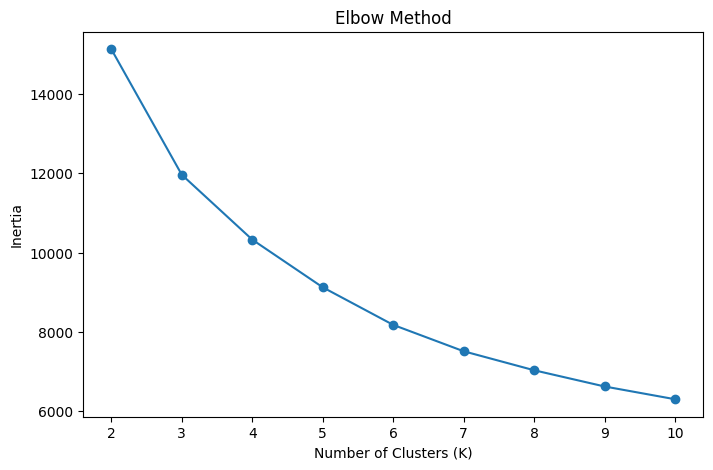

In [140]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.show()

In [141]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

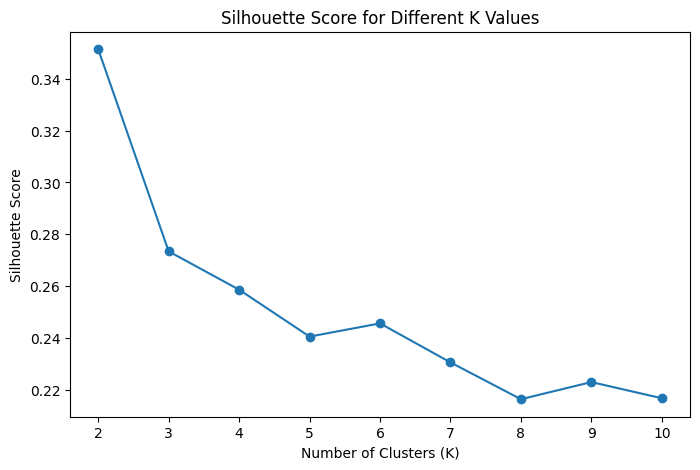

In [142]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.title('Silhouette Score for Different K Values')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.show()

In [143]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K={k}: {score:.4f}")

K=2: 0.3513
K=3: 0.2735
K=4: 0.2587
K=5: 0.2406
K=6: 0.2457
K=7: 0.2307
K=8: 0.2165
K=9: 0.2231
K=10: 0.2169


In [144]:
from sklearn.metrics import davies_bouldin_score

for k in [2, 3, 4]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(scaled_features)

    score = davies_bouldin_score(scaled_features, labels)

    print(f"K={k}: Davies-Bouldin Score = {score:.4f}")

K=2: Davies-Bouldin Score = 1.0615
K=3: Davies-Bouldin Score = 1.2323
K=4: Davies-Bouldin Score = 1.2369


In [145]:
final_kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_data['CustomerSegment'] = final_kmeans.fit_predict(scaled_features)

In [146]:
customer_data['CustomerSegment'].value_counts()

,count
CustomerSegment,
1,1652
3,947
2,940
0,799


In [147]:
cluster_profile = customer_data.groupby('CustomerSegment')[
    [
        'TotalSpending',
        'NumberOfOrders',
        'TotalQuantity',
        'UniqueProducts',
        'AverageOrderValue',
        'Recency'
    ]
].mean()

cluster_profile

,TotalSpending,NumberOfOrders,TotalQuantity,UniqueProducts,AverageOrderValue,Recency
CustomerSegment,,,,,,
0,310.499825,1.292866,165.444305,17.873592,254.782042,266.735920
1,1057.555062,2.941283,632.779056,55.991525,442.658826,63.651332
2,7087.972926,11.758511,4085.424468,151.982979,759.209082,25.224468
3,267.751882,1.675818,158.366420,18.108765,179.353848,58.183738


In [148]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

pca_features = pca.fit_transform(scaled_features)

customer_data['PCA1'] = pca_features[:, 0]
customer_data['PCA2'] = pca_features[:, 1]

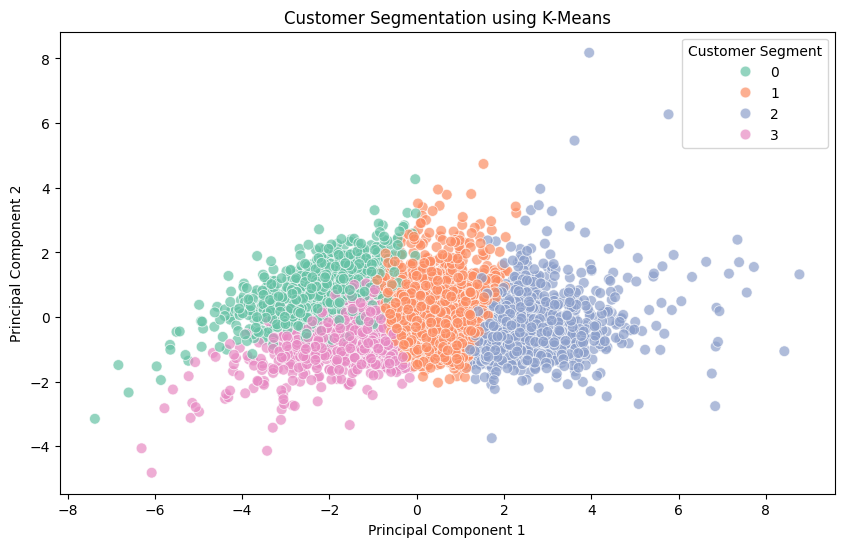

In [149]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_data,
    x='PCA1',
    y='PCA2',
    hue='CustomerSegment',
    palette='Set2',
    s=60,
    alpha=0.7
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Customer Segment')

plt.show()

In [150]:
segment_names = {
    0: 'Regular Customers',
    1: 'Low-Value Customers',
    2: 'High-Value Loyal Customers',
    3: 'Inactive/At-Risk Customers'
}

customer_data['SegmentName'] = customer_data['CustomerSegment'].map(segment_names)

In [151]:
customer_data[['CustomerSegment', 'SegmentName']].head()

,CustomerSegment,SegmentName
CustomerID,,
12346.0,2,High-Value Loyal Customers
12347.0,2,High-Value Loyal Customers
12348.0,1,Low-Value Customers
12349.0,1,Low-Value Customers
12350.0,0,Regular Customers


In [152]:
final_profile = customer_data.groupby('SegmentName').agg(
    Customers=('CustomerSegment', 'count'),
    TotalSpending=('TotalSpending', 'mean'),
    NumberOfOrders=('NumberOfOrders', 'mean'),
    TotalQuantity=('TotalQuantity', 'mean'),
    UniqueProducts=('UniqueProducts', 'mean'),
    AverageOrderValue=('AverageOrderValue', 'mean'),
    Recency=('Recency', 'mean')
).round(2)

final_profile

,Customers,TotalSpending,NumberOfOrders,TotalQuantity,UniqueProducts,AverageOrderValue,Recency
SegmentName,,,,,,,
High-Value Loyal Customers,940,7087.97,11.76,4085.42,151.98,759.21,25.22
Inactive/At-Risk Customers,947,267.75,1.68,158.37,18.11,179.35,58.18
Low-Value Customers,1652,1057.56,2.94,632.78,55.99,442.66,63.65
Regular Customers,799,310.50,1.29,165.44,17.87,254.78,266.74


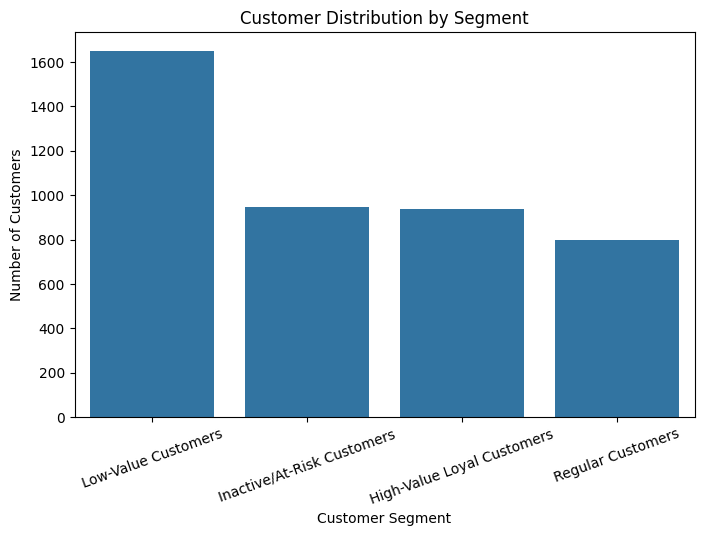

In [153]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=customer_data,
    x='SegmentName',
    order=final_profile.sort_values('Customers', ascending=False).index
)

plt.title('Customer Distribution by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)

plt.show()

In [154]:
business_recommendations = pd.DataFrame({
    'Segment': [
        'High-Value Loyal Customers',
        'Regular Customers',
        'Low-Value Customers',
        'Inactive/At-Risk Customers'
    ],
    'Key_Characteristics': [
        'High spending, frequent purchases, high product diversity, recent activity',
        'Moderate spending and purchase frequency with reasonable product diversity',
        'Low spending, few orders, and limited product diversity',
        'Very low purchase frequency and very high recency'
    ],
    'Business_Strategy': [
        'VIP rewards, loyalty programs, premium product recommendations',
        'Upselling, cross-selling, personalized recommendations',
        'Low-cost promotions, product bundles, repeat-purchase incentives',
        'Win-back campaigns, re-engagement offers, targeted discounts'
    ]
})

business_recommendations

,Segment,Key_Characteristics,Business_Strategy
0,High-Value Loyal Customers,"High spending, frequent purchases, high produc...","VIP rewards, loyalty programs, premium product..."
1,Regular Customers,Moderate spending and purchase frequency with ...,"Upselling, cross-selling, personalized recomme..."
2,Low-Value Customers,"Low spending, few orders, and limited product ...","Low-cost promotions, product bundles, repeat-p..."
3,Inactive/At-Risk Customers,Very low purchase frequency and very high recency,"Win-back campaigns, re-engagement offers, targ..."


In [155]:
customer_data.to_csv('customer_segmentation_results.csv', index=True)